In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import data_processing.data as data
import data_processing2.data as data2
import data_processing2.features as features
import data_processing2.features_scaled as feature_scaled
import helpers.metrics as metrics
from data_processing.scalers import SignedLogTransformer
from data_processing2.constants import *
from data_processing2.utils2 import display_basic_stats, analyze_row_completeness, filter_rows_by_completeness, read_solar_phases, add_solar_cycle_features
from data_processing2.imputation_logic import impute_missing_values, train_imputation_models

from data_processing.scalers import SignedLogTransformer, SinhArcsinhTransformer, ClippingTransformer, YeoJohnsonTransformer, apply_transformation_pipeline_raw, apply_inverse_transformation_pipeline_raw
from data_processing2.viz import plot_clean_distributions
from data_processing2.new_target import add_storm_duration_target
from data_processing2.targets.ner_target import add_storm_boundary_target
import matplotlib.pyplot as plt


### Reading data

Load raw solar wind and magnetosphere observations from 1976-2025. Data is read via `data_processing2.data.read_data()`. Solar cycle phases are added based on `solar_phase.csv`.

In [2]:
solar_phases = read_solar_phases("solar_phase.csv")

full_raw_data = data2.read_data(r"solar_cycles\19761101_20251130.fmt", r"solar_cycles\19761101_20251130.lst")["x"]
full_raw_data = full_raw_data.sort_values(by=["YEAR", "DOY", "Hour"])
full_raw_data = add_solar_cycle_features(full_raw_data, solar_phases, FULL_DATE_COLUMN, missing_rate=0.30)

print(full_raw_data.columns, "len: ", len(full_raw_data))
full_raw_data.head()

Index(['YEAR', 'DOY', 'Hour', 'Scalar B, nT', 'Vector B Magnitude,nT',
       'Lat. Angle of B (GSE)', 'Long. Angle of B (GSE)', 'BX, nT (GSE, GSM)',
       'BY, nT (GSE)', 'BZ, nT (GSE)', 'BY, nT (GSM)', 'BZ, nT (GSM)',
       'SW Plasma Temperature, K', 'SW Proton Density, N/cm^3',
       'SW Plasma Speed, km/s', 'SW Plasma flow long. angle',
       'SW Plasma flow lat. angle', 'Alpha/Prot. ratio', 'Flow pressure',
       'E elecrtric field', 'Plasma Beta', 'Alfen mach number',
       'Magnetosonic Much num.', 'Quasy-Invariant', 'R (Sunspot No.)',
       'Dst-index, nT', 'AE-index, nT', 'Lyman_alpha', 'Proton flux (>10 Mev)',
       'full_date', 'solar_phase', 'solar_cycle'],
      dtype='str') len:  430248


,YEAR,DOY,Hour,"Scalar B, nT","Vector B Magnitude,nT",Lat. Angle of B (GSE),Long. Angle of B (GSE),"BX, nT (GSE, GSM)","BY, nT (GSE)","BZ, nT (GSE)",...,Magnetosonic Much num.,Quasy-Invariant,R (Sunspot No.),"Dst-index, nT","AE-index, nT",Lyman_alpha,Proton flux (>10 Mev),full_date,solar_phase,solar_cycle
0,1976,306,00,4.3,3.6,-15.6,151.0,-3.0,1.7,-1.0,...,6.6,0.0094,0,-41,9999,0.006119,0.33,1976-11-01 00:00:00,min,21
1,1976,306,01,4.3,4.0,15.7,157.7,-3.6,1.5,1.1,...,6.6,0.0097,0,-38,9999,0.006119,0.34,1976-11-01 01:00:00,min,21
2,1976,306,02,4.2,3.4,7.1,194.4,-3.3,-0.8,0.4,...,6.7,0.0096,0,-36,9999,0.006119,0.38,1976-11-01 02:00:00,min,21
3,1976,306,03,4.1,2.8,9.1,136.0,-2.0,1.9,0.4,...,6.8,0.0085,0,-35,9999,0.006119,0.40,1976-11-01 03:00:00,min,21
4,1976,306,04,3.7,3.1,11.0,147.6,-2.5,1.6,0.6,...,6.9,0.0072,0,-35,9999,0.006119,0.35,1976-11-01 04:00:00,min,21


### Imputation

Handle missing values using regression-based imputation models. See `data_processing2.imputation_logic.train_imputation_models()` for the approach.

In [3]:
processed_full_data = data2.process_dataset(full_raw_data, replace_outliers=True)
imputation_models = train_imputation_models(processed_full_data, 30, [DST_COLUMN, AE_COLUMN, ALPHA_PROTON_RATIO_COL, FULL_DATE_COLUMN, SOLAR_CYCLE, SOLAR_PHASE])
full_data_imp = impute_missing_values(processed_full_data, imputation_models, 30)

del imputation_models

Replacing outliers...
Done replacing outliers with mean.
Trained Vector B Magnitude,nT: R²=0.980, MSE=0.197, N=375719
Trained Lat. Angle of B (GSE): R²=0.850, MSE=120.528, N=375719
Trained Long. Angle of B (GSE): R²=0.847, MSE=1531.538, N=375719
Trained BX, nT (GSE, GSM): R²=0.972, MSE=0.382, N=375719
Trained BY, nT (GSM): R²=0.969, MSE=0.504, N=375699
Trained BZ, nT (GSM): R²=0.990, MSE=0.103, N=375699
Trained Scalar B, nT: R²=0.986, MSE=0.149, N=375719
Trained SW Plasma Speed, km/s: R²=0.988, MSE=120.718, N=368955
Trained SW Proton Density, N/cm^3: R²=0.989, MSE=0.335, N=365666
Trained SW Plasma Temperature, K: R²=0.983, MSE=161658036.926, N=355783
Trained Plasma Beta: R²=0.961, MSE=0.695, N=355156
Trained Flow pressure: R²=0.986, MSE=0.049, N=365666
Trained E elecrtric field: R²=0.991, MSE=0.020, N=368652
Trained Magnetosonic Much num.: R²=0.991, MSE=0.011, N=355156
Imputed 20 values for BY, nT (GSM)
Imputed 20 values for BZ, nT (GSM)
Imputed 6764 values for SW Plasma Speed, km/s
Im

### Split Data

Split by solar cycle rather than time to ensure independence between train/val/test. Train on cycles 20, 21, 23, 24; validate on cycle 22; test on cycle 25. This avoids data leakage from overlapping solar activity patterns.

In [4]:
# print(full_data_imp["full_date"].min(), full_data_imp["full_date"].max())
# raw_train_data, raw_test_data = data.temporal_split(full_data_imp, "full_date", "2007-01-01")
# raw_train_data, raw_val_data = data.temporal_split(raw_train_data, "full_date", "2005-01-01")
# print(len(raw_train_data), len(raw_val_data), len(raw_test_data))

# print(raw_train_data["full_date"].min(), raw_train_data["full_date"].max())
# print(raw_val_data["full_date"].min(), raw_val_data["full_date"].max())
# print(raw_test_data["full_date"].min(), raw_test_data["full_date"].max())

# train_date_min = raw_train_data["full_date"].min()
# train_date_max = raw_train_data["full_date"].max()
# val_date_min = raw_val_data["full_date"].min()
# val_date_max = raw_val_data["full_date"].max()
# test_date_min = raw_test_data["full_date"].min()
# test_date_max = raw_test_data["full_date"].max()

raw_train_data = full_data_imp[full_data_imp["solar_cycle"].isin([20, 21, 23, 24])]
raw_test_data = full_data_imp[full_data_imp["solar_cycle"].isin([25])]
raw_val_data = full_data_imp[full_data_imp["solar_cycle"].isin([22])]

print(len(raw_train_data), len(raw_val_data), len(raw_test_data))

268056 89136 73056


In [5]:
print(raw_train_data["full_date"].min(), raw_train_data["full_date"].max())
print(raw_val_data["full_date"].min(), raw_val_data["full_date"].max())
print(raw_test_data["full_date"].min(), raw_test_data["full_date"].max())

1976-11-01 00:00:00 2017-07-31 23:00:00
1985-07-01 00:00:00 1995-08-31 23:00:00
2017-08-01 00:00:00 2025-11-30 23:00:00


### Initial assessment

Baseline statistics: storm rate, missing data, sample size. Validation has higher storm rate (10%) than train (5.5%) and test (2.8%), which is expected due to solar cycle selection.

In [6]:
display_basic_stats(raw_train_data, -50)
display_basic_stats(raw_val_data, -50)
display_basic_stats(raw_test_data, -50)

Full data: > Len: 268056, > Storms: 14783; 5.51%, > Rows with NaN: 131503 (49.06%)
Full data: > Len: 89136, > Storms: 8965; 10.06%, > Rows with NaN: 62514 (70.13%)
Full data: > Len: 73056, > Storms: 2074; 2.84%, > Rows with NaN: 40084 (54.87%)


### Processing data

Apply feature engineering and transformations via `data_processing2.features_scaled.compute_features()`. This module (see `data_processing2/features_scaled.py`) computes 177 features including lags, domain features (Alfvén speed, coupling efficiency, loading states), and applies Box-Cox-like transformations (signed log, sinh-arcsinh) to normalize distributions.

In [7]:
# target_transforms = [ClippingTransformer(clip_min=-250, clip_max=50), SinhArcsinhTransformer(-0.1, 0.4)]
# target_transforms = [SinhArcsinhTransformer(-0.1, 0.4)]
# target_transforms = [ClippingTransformer(clip_min=-250, clip_max=50)]
target_transforms = []
# target_transforms = [ClippingTransformer(clip_min=-250, clip_max=50), SignedLogTransformer(), SinhArcsinhTransformer(1, 0.4)]
column_transforms = {
    BZ_COL: [SignedLogTransformer()],
    BY_COL: [SignedLogTransformer()],
    # BX_COL: [SignedLogTransformer()],
    SCALAR_B_COL: [SignedLogTransformer()],
    SW_SPEED_COL: [SinhArcsinhTransformer(0.1, 0.5)],
    SW_DENSITY_COL: [SignedLogTransformer()],
    SW_TEMP_COL: [SignedLogTransformer(), SinhArcsinhTransformer(0, 0.4)],
    PLASMA_BETA_COL: [SignedLogTransformer(), SinhArcsinhTransformer(0, 0.5)],
    FLOW_PRESSURE_COL: [SignedLogTransformer(), SinhArcsinhTransformer(0, 0.5)],
    E_FIELD_COL: [SinhArcsinhTransformer(0.1, 0.5)],
    ALPHA_PROTON_RATIO_COL: [SinhArcsinhTransformer(0.1, 0.5), SignedLogTransformer()],
    ENERGY_LOADING_STATE_COL: [SinhArcsinhTransformer(0.1, 0.5), SignedLogTransformer()],
    COUPLING_EFFICIENCY_STATE: [SinhArcsinhTransformer(0.1, 0.5), SignedLogTransformer()],
    MAGNETOTAIL_LOADING_STATE_COL: [SinhArcsinhTransformer(0.1, 0.5), SignedLogTransformer()],
}

# column_transforms = {
#     BZ_COL: [],
#     BY_COL: [],
#     # BX_COL: [],
#     SCALAR_B_COL: [],
#     SW_SPEED_COL: [],
#     SW_DENSITY_COL: [],
#     SW_TEMP_COL: [],
#     PLASMA_BETA_COL: [],
#     FLOW_PRESSURE_COL: [],
#     E_FIELD_COL: [],
#     ALPHA_PROTON_RATIO_COL: [],
#     ENERGY_LOADING_STATE_COL: [],
#     COUPLING_EFFICIENCY_STATE: [],
#     MAGNETOTAIL_LOADING_STATE_COL: [],
# }

TRANSFORMED_STORM_THRESHOLD = target_transforms[0].transform([STORM_THRESHOLD])[0] if target_transforms else STORM_THRESHOLD

nan_train_data, fit_target_transforms, fit_column_transforms = feature_scaled.compute_features(
    raw_train_data, target_transforms=target_transforms, column_transforms=column_transforms, fit_transform=True
)

nan_val_data, fit_target_transforms, fit_column_transforms = feature_scaled.compute_features(
    raw_val_data, target_transforms=target_transforms, column_transforms=column_transforms, fit_transform=False
)


nan_test_data, fit_target_transforms, fit_column_transforms = feature_scaled.compute_features(
    raw_test_data, target_transforms=target_transforms, column_transforms=column_transforms, fit_transform=False
)

--- Working on domain features..
 > Done!
--- Working on domain features..
 > Done!
--- Working on domain features..
 > Done!


### Checking the scale of data

This is a sanity check to ensure all features are properly scaled after transformations. Features should be in the range ~1e-2 to 1e+2 to avoid numerical instability during XGBoost training.

In [8]:
def quick_scale_check(dataset: pd.DataFrame) -> None:
    """Quick visual check of column scales."""
    import numpy as np
    
    print("\nColumn Scales:")
    print("-" * 60)
    
    for col in dataset.columns:
        if pd.api.types.is_numeric_dtype(dataset[col]):
            max_abs = dataset[col].abs().max()
            
            if pd.isna(max_abs) or max_abs == 0:
                scale = "1e0 (zero/nan)"
            else:
                order = int(np.floor(np.log10(max_abs)))
                scale = f"1e{order:+3d}"  # Format: 1e+04, 1e-02
                
            print(f"{col:40s} : {scale:15s} (max_abs: {max_abs:.2e})")

quick_scale_check(nan_test_data)


Column Scales:
------------------------------------------------------------
BY, nT (GSM)                             : 1e -1           (max_abs: 6.81e-01)
BZ, nT (GSM)                             : 1e -1           (max_abs: 6.63e-01)
Scalar B, nT                             : 1e -1           (max_abs: 6.82e-01)
SW Plasma Speed, km/s                    : 1e -1           (max_abs: 2.97e-01)
SW Proton Density, N/cm^3                : 1e -1           (max_abs: 6.90e-01)
SW Plasma Temperature, K                 : 1e -2           (max_abs: 4.69e-02)
Plasma Beta                              : 1e -2           (max_abs: 8.06e-02)
Flow pressure                            : 1e -2           (max_abs: 7.37e-02)
E elecrtric field                        : 1e -1           (max_abs: 4.24e-01)
Dst-index, nT                            : 1e +2           (max_abs: 4.06e+02)
Alpha/Prot. ratio                        : 1e -1           (max_abs: 1.65e-01)
solar_cycle                              : 1e +1      

In [9]:
display_basic_stats(nan_train_data, TRANSFORMED_STORM_THRESHOLD)
display_basic_stats(nan_val_data, TRANSFORMED_STORM_THRESHOLD)
display_basic_stats(nan_test_data, TRANSFORMED_STORM_THRESHOLD)


_ = analyze_row_completeness(nan_train_data, [DST_COLUMN])
_ = analyze_row_completeness(nan_val_data, [DST_COLUMN])
_ = analyze_row_completeness(nan_test_data, [DST_COLUMN])

Full data: > Len: 268056, > Storms: 14783; 5.51%, > Rows with NaN: 268052 (100.00%)
Full data: > Len: 89136, > Storms: 8965; 10.06%, > Rows with NaN: 89136 (100.00%)
Full data: > Len: 73056, > Storms: 2074; 2.84%, > Rows with NaN: 73056 (100.00%)
Row Completeness Analysis:    Mean:   9.6%   Median: 7.0%   Std:    9.6%
Row Completeness Analysis:    Mean:   26.3%   Median: 16.4%   Std:    19.9%
Row Completeness Analysis:    Mean:   6.8%   Median: 6.4%   Std:    2.8%


### Dummy target

Create independent copies of the scaled datasets. This allows training multiple models (e.g., different forecast horizons) without re-running the expensive feature engineering step.

In [10]:
new_nan_train_data = nan_train_data.copy()
new_nan_val_data = nan_val_data.copy()
new_nan_test_data = nan_test_data.copy()

### Adds delay 

Shift target (Dst-index) backwards by 4 hours to create a 4-hour forecast horizon. The model learns to predict Dst 4 hours in advance using current conditions. The prediction horizion can be modified to 6, 8, 12 or anything else.

In [11]:
# new_nan_val_data["storm_boundary"].hist()
import numpy as np

def add_storm_boundary_lags(df, target_col='storm_boundary', max_lag=4):
    """Add lagged storm boundary features."""
    
    # Current state
    df[f'{target_col}_current'] = df[target_col]
    
    # Past states
    for lag in range(1, max_lag + 1):
        df[f'{target_col}_past_{lag}h'] = df[target_col].shift(lag)
    
    return df

delayed_nan_train_data = new_nan_train_data.copy()
delayed_nan_train_data = add_storm_boundary_lags(delayed_nan_train_data, DST_COLUMN, max_lag=4)
delayed_nan_train_data[DST_COLUMN] = delayed_nan_train_data[DST_COLUMN].shift(-4)
delayed_nan_train_data = delayed_nan_train_data.dropna(subset=[DST_COLUMN])

delayed_nan_test_data = new_nan_test_data.copy()
delayed_nan_test_data = add_storm_boundary_lags(delayed_nan_test_data, DST_COLUMN, max_lag=4)
delayed_nan_test_data[DST_COLUMN] = delayed_nan_test_data[DST_COLUMN].shift(-4)
delayed_nan_test_data = delayed_nan_test_data.dropna(subset=[DST_COLUMN])

delayed_nan_val_data = new_nan_val_data.copy()
delayed_nan_val_data = add_storm_boundary_lags(delayed_nan_val_data, DST_COLUMN, max_lag=4)
delayed_nan_val_data[DST_COLUMN] = delayed_nan_val_data[DST_COLUMN].shift(-4)
delayed_nan_val_data = delayed_nan_val_data.dropna(subset=[DST_COLUMN])

# print(delayed_nan_train_data[STORM_BOUNDARY][50500:50525].values)
# print(new_nan_train_data[STORM_BOUNDARY][50500:50525].values)

### Filtering NaN rows

Keep only rows with >=50% feature completeness.

In [12]:
train_data = filter_rows_by_completeness(delayed_nan_train_data, 50, [DST_COLUMN, FULL_DATE_COLUMN])
val_data = filter_rows_by_completeness(delayed_nan_val_data, 50, [DST_COLUMN, FULL_DATE_COLUMN])
test_data = filter_rows_by_completeness(delayed_nan_test_data, 50, [DST_COLUMN, FULL_DATE_COLUMN])

train_data[SOLAR_PHASE] = train_data[SOLAR_PHASE].astype(dtype="category")
val_data[SOLAR_PHASE] = val_data[SOLAR_PHASE].astype(dtype="category")
test_data[SOLAR_PHASE] = test_data[SOLAR_PHASE].astype(dtype="category")

_ = analyze_row_completeness(train_data, [DST_COLUMN])
_ = analyze_row_completeness(val_data, [DST_COLUMN])
_ = analyze_row_completeness(test_data, [DST_COLUMN])

Completeness filter (≥50%): kept 265,887/268,052 rows (99.2%), removed 2,165
Completeness filter (≥50%): kept 82,316/89,132 rows (92.4%), removed 6,816
Completeness filter (≥50%): kept 73,038/73,052 rows (100.0%), removed 14
Row Completeness Analysis:    Mean:   9.0%   Median: 6.8%   Std:    8.6%
Row Completeness Analysis:    Mean:   23.5%   Median: 10.2%   Std:    18.8%
Row Completeness Analysis:    Mean:   6.6%   Median: 6.2%   Std:    2.6%


In [13]:
print(train_data.columns)

Index(['BY, nT (GSM)', 'BZ, nT (GSM)', 'Scalar B, nT', 'SW Plasma Speed, km/s',
       'SW Proton Density, N/cm^3', 'SW Plasma Temperature, K', 'Plasma Beta',
       'Flow pressure', 'E elecrtric field', 'full_date',
       ...
       'Flow pressure_lag_8', 'E elecrtric field_lag_4',
       'E elecrtric field_lag_8', 'Alpha/Prot. ratio_lag_8',
       'Alpha/Prot. ratio_lag_12', 'Dst-index, nT_current',
       'Dst-index, nT_past_1h', 'Dst-index, nT_past_2h',
       'Dst-index, nT_past_3h', 'Dst-index, nT_past_4h'],
      dtype='str', length=177)


### Training single XGBoost

Train a baseline XGBoost regression model with weighted samples (storms weighted higher). Uses MAE loss with early stopping on validation set. This model serves as a reference before hyperparameter tuning.

In [14]:
# Data preparation
import xgboost as xgb
from helpers.xgboost_objectives import create_focal_objective, create_focal_eval

# Create focal objective
focal_obj = create_focal_objective(gamma=1.0)
focal_eval = create_focal_eval(gamma=1.0)
# focal_eval = create_focal_eval(gamma=2.0)

x_train = train_data.drop(columns=[DST_COLUMN, FULL_DATE_COLUMN, SOLAR_CYCLE]) # careful for FISM
# y_train = train_data[DST_COLUMN]
y_train = train_data[DST_COLUMN]

def get_weights(y, storm_threshold=-50, non_storm_weight=None, storm_weight=None):
    is_storm = y <= storm_threshold
    
    if non_storm_weight is None or storm_weight is None:
        # Automatic balancing: equal total weight for each class
        n_storms = is_storm.sum()
        n_non_storms = (~is_storm).sum()
        
        # Set non-storm weight to 1.0, scale storm weight proportionally
        non_storm_weight = 1.0
        storm_weight = n_non_storms / n_storms if n_storms > 0 else 1.0
    
    return np.where(is_storm, storm_weight, non_storm_weight)

sample_weights = get_weights(
        y_train, 
        storm_threshold = -50,
        non_storm_weight = 0.3,
        storm_weight = 0.7,
    )

dtrain = xgb.DMatrix(x_train, label=y_train, enable_categorical=True, weight=sample_weights)

x_val = val_data.drop(columns=[DST_COLUMN, FULL_DATE_COLUMN, SOLAR_CYCLE]) # careful for FISM
# y_val = val_data[DST_COLUMN]
y_val = val_data[DST_COLUMN]

dvalid = xgb.DMatrix(x_val, label=y_val, enable_categorical=True)

x_test = test_data.drop(columns=[DST_COLUMN, FULL_DATE_COLUMN, SOLAR_CYCLE]) # careful for FISM
# y_test = test_data[DST_COLUMN]
y_test = test_data[DST_COLUMN]

dtest = xgb.DMatrix(x_test, label=y_test, enable_categorical=True)

base_params = {

    # "objective": "multi:softmax",  # Multi-class classification
    # "num_class": 3,                # O, B-STORM, I-STORM
    # "eval_metric": "mlogloss",     # Multi-class log loss

    # "objective": "reg:squarederror",
    "objective": "reg:absoluteerror",
    # "objective": 'count:poisson',
    # "objective": "reg:pseudohubererror",
    # "objective": "reg:quantileerror",
    # "quantile_alpha": [0.85],
    "tree_method": "hist",  # Faster than exact for initial tests
    "booster": "gbtree",    # Start simple (no dart/linear yet)
    "eta": 0.01,             # Moderate learning rate
    "max_depth": 5,         # Balanced depth
    "min_child_weight": 0.1,  # Prevent overfitting to rare storms
    "subsample": 0.8,       # Slight randomness
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8, # new
    "colsample_bynode": 0.4,
    "lambda": 0.5,          # Moderate L2 reg
    "alpha": 0.1,           # Mild L1 reg
    "gamma": 0.01,           # Minimum loss reduction
    "max_delta_step": 0,    # Control extreme value sensitivity
    "seed": 42,
    # "disable_default_eval_metric": True,
    "eval_metric": "mae"
}

xgb_model = xgb.train(
    params = base_params,
    dtrain = dtrain,
    evals=[(dvalid, "val")],
    num_boost_round=2000,
    early_stopping_rounds=75,
    verbose_eval=True,
    # obj=lambda y_pred, dtrain: xgb_asymmetric_objective(y_pred, dtrain, alpha=1.0, beta=3.0)
    # obj=focal_obj,
    # custom_metric=focal_eval,
)

[0]	val-mae:18.05135
[1]	val-mae:17.91129
[2]	val-mae:17.78054
[3]	val-mae:17.63931
[4]	val-mae:17.52284
[5]	val-mae:17.40310
[6]	val-mae:17.27368
[7]	val-mae:17.14772
[8]	val-mae:17.01637
[9]	val-mae:16.89330
[10]	val-mae:16.77572
[11]	val-mae:16.65410
[12]	val-mae:16.53304
[13]	val-mae:16.41311
[14]	val-mae:16.30146
[15]	val-mae:16.19655
[16]	val-mae:16.08297
[17]	val-mae:15.96335
[18]	val-mae:15.86736
[19]	val-mae:15.75660
[20]	val-mae:15.65425
[21]	val-mae:15.55676
[22]	val-mae:15.45019
[23]	val-mae:15.34421
[24]	val-mae:15.24224
[25]	val-mae:15.14589
[26]	val-mae:15.04328
[27]	val-mae:14.94811
[28]	val-mae:14.84646
[29]	val-mae:14.75624
[30]	val-mae:14.66135
[31]	val-mae:14.56670
[32]	val-mae:14.47357
[33]	val-mae:14.38332
[34]	val-mae:14.29352
[35]	val-mae:14.20242
[36]	val-mae:14.11501
[37]	val-mae:14.03304
[38]	val-mae:13.94497
[39]	val-mae:13.85676
[40]	val-mae:13.77054
[41]	val-mae:13.68987
[42]	val-mae:13.60576
[43]	val-mae:13.52074
[44]	val-mae:13.44336
[45]	val-mae:13.3733

### Hyperparam Fine-Tuning

Optuna-based hyperparameter optimization across 400 trials. Optimizes for F1 score (storm detection), jointly tuning sample weights, tree depth, regularization, and learning rate. Results stored in pickle for reproducibility.

In [ ]:
import xgboost as xgb
import optuna
import numpy as np
import joblib

# Data preparation
x_train = train_data.drop(columns=[DST_COLUMN, FULL_DATE_COLUMN])
y_train = train_data[DST_COLUMN]
x_val = val_data.drop(columns=[DST_COLUMN, FULL_DATE_COLUMN])
y_val = val_data[DST_COLUMN]

def get_weights(y, storm_threshold=TRANSFORMED_STORM_THRESHOLD, non_storm_weight=0.5, storm_weight=10.0):
    return np.where(y < storm_threshold, storm_weight, non_storm_weight)

# Fixed validation set (no weights)
dvalid = xgb.DMatrix(x_val, label=y_val, enable_categorical=True)

def objective(trial):
    non_storm_weight = trial.suggest_float("non_storm_weight", 0.10, 1.50)
    storm_weight = trial.suggest_float("storm_weight", 2.0, 15.0)
    sample_weights = get_weights(
        y_train, 
        non_storm_weight = non_storm_weight,
        storm_weight = storm_weight
    )
    dtrain = xgb.DMatrix(x_train, label=y_train, weight=sample_weights, enable_categorical=True)

    feature_names = x_train.columns.tolist()

    eta = trial.suggest_float("eta", 0.01, 0.3, log=True)
    if eta < 0.1:
        num_boost_round = trial.suggest_int("num_boost_round", 50, 700, step=50)
    else:
        num_boost_round = trial.suggest_int("num_boost_round", 50, 500, step=50)

    param = {
        "verbosity": 0,
        "objective": "reg:absoluteerror",
        "tree_method": "hist",
        "booster": trial.suggest_categorical("booster", ["gbtree"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),  # Add this
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.3, 0.8),    # Add this
        "max_delta_step": trial.suggest_float("max_delta_step", 0, 10),  
        "eta": eta,
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 0.5, log=True),
    }

    if param["booster"] == "gblinear":
        # Remove tree-specific parameters for gblinear
        param.pop("max_depth", None)
        param.pop("min_child_weight", None)
        param.pop("gamma", None)
        param.pop("subsample", None)
        param.pop("colsample_bytree", None)
        param.pop("colsample_bylevel", None)
        param.pop("colsample_bynode", None)
        param.pop("max_delta_step", None)
        
        # Add gblinear-specific parameters
        param.update({
            "updater": trial.suggest_categorical("updater", ["shotgun", "coord_descent"]),
            "feature_selector": trial.suggest_categorical("feature_selector", ["cyclic", "shuffle"]),
        })

    elif param["booster"] == "dart":
        param.update({
            "rate_drop": trial.suggest_float("rate_drop", 0.1, 0.5),
            "skip_drop": trial.suggest_float("skip_drop", 0.1, 0.5),
            "one_drop": trial.suggest_categorical("one_drop", [0, 1]),
            "normalize_type": trial.suggest_categorical("normalize_type", ["tree", "forest"]),
        })

    # Train with early stopping
    bst = xgb.train(
        param,
        dtrain,
        evals=[(dvalid, "val")],
        early_stopping_rounds=50,
        verbose_eval=False,
        num_boost_round=num_boost_round,
    )

    # Validation predictions
    val_preds = bst.predict(dvalid)
    
    # Calculate metrics
    _y_val = apply_inverse_transformation_pipeline_raw(y_val, target_transforms)
    _y_val_preds = apply_inverse_transformation_pipeline_raw(val_preds, target_transforms)
    metric_results = metrics.compute_forecast_metrics(_y_val, _y_val_preds, storm_threshold=STORM_THRESHOLD)
    
    # Store model and weights
    trial.set_user_attr("model", bst)
    trial.set_user_attr("storm_weight", storm_weight)
    trial.set_user_attr("non_storm_weight", non_storm_weight)
    trial.set_user_attr("precision", metric_results["precision"])
    trial.set_user_attr("recall", metric_results["recall"])
    trial.set_user_attr("f1_score", metric_results["f1_score"])
    trial.set_user_attr("mae", metric_results["mae"])

    del dtrain, val_preds  # Free memory
    import gc; gc.collect()
    
    return metric_results["f1_score"]

# Configure study with weight-aware optimization
sampler = optuna.samplers.TPESampler(
    multivariate=True, 
    warn_independent_sampling=False,
    n_startup_trials=60,  # Good exploration across 3 boosters
    n_ei_candidates=24   # Balanced for 500 trials
)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=20,  # Reduced from 30
    n_warmup_steps=15,    # Reduced from 25  
    interval_steps=10     # Reduced from 15 - more frequent pruning
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="xgboost_fast_tree_estimation"
)

study.optimize(
    objective, 
    n_trials=400,
    timeout=10800,
    n_jobs=4,
)

print(f"Best trial: {study.best_trials}")
print(f"Best F1: {study.best_trials[0].values[0]:.3f}")
# print(f"Best MAE: {study.best_trials[0].values[1]:.2f}")

# Save best models and analysis
joblib.dump(study, "xgboost_fast_tree_estimation_study.pkl")

[I 2026-05-17 15:47:20,089] A new study created in memory with name: xgboost_fast_tree_estimation



STORM DETECTION CLASSIFICATION REPORT
Storm threshold: -50 nT
Total samples: 82334
True storm hours: 8678 (10.5%)
Predicted storm hours: 16122 (19.6%)

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-storm      0.990     0.890     0.938     73656
       Storm      0.498     0.926     0.648      8678

    accuracy                          0.894     82334
   macro avg      0.744     0.908     0.793     82334
weighted avg      0.938     0.894     0.907     82334


Confusion Matrix Summary:
True Positives (storms correctly detected): 8035
False Positives (false alarms): 8087
False Negatives (missed storms): 643
True Negatives (quiet times correctly identified): 65569

Critical Events Detection Rate: 92.6%


[I 2026-05-17 15:47:57,416] Trial 2 finished with value: 0.6479838709677419 and parameters: {'non_storm_weight': 0.6657299029760225, 'storm_weight': 14.06788348557117, 'eta': 0.010794845973079843, 'num_boost_round': 50, 'booster': 'gbtree', 'lambda': 0.006569173034603443, 'alpha': 1.79534653397737, 'subsample': 0.9039772331864596, 'colsample_bytree': 0.9658046100047843, 'colsample_bylevel': 0.739582899721232, 'colsample_bynode': 0.4433086144913308, 'max_delta_step': 7.229477410784605, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 0.11391616535205037}. Best is trial 2 with value: 0.6479838709677419.



STORM DETECTION CLASSIFICATION REPORT
Storm threshold: -50 nT
Total samples: 82334
True storm hours: 8678 (10.5%)
Predicted storm hours: 10166 (12.3%)

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-storm      0.978     0.959     0.968     73656
       Storm      0.700     0.821     0.756      8678

    accuracy                          0.944     82334
   macro avg      0.839     0.890     0.862     82334
weighted avg      0.949     0.944     0.946     82334


Confusion Matrix Summary:
True Positives (storms correctly detected): 7121
False Positives (false alarms): 3045
False Negatives (missed storms): 1557
True Negatives (quiet times correctly identified): 70611

Critical Events Detection Rate: 82.1%


[I 2026-05-17 15:48:19,041] Trial 1 finished with value: 0.7557843345361919 and parameters: {'non_storm_weight': 1.0652026012856664, 'storm_weight': 9.517860256796233, 'eta': 0.0621569627205376, 'num_boost_round': 100, 'booster': 'gbtree', 'lambda': 2.1368370105233798e-06, 'alpha': 0.0019626801661594214, 'subsample': 0.7286103812462741, 'colsample_bytree': 0.98514077666808, 'colsample_bylevel': 0.9261606419600957, 'colsample_bynode': 0.35448876995518136, 'max_delta_step': 2.552198075020735, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 8.340976688172983e-08}. Best is trial 1 with value: 0.7557843345361919.


### Metrics

Evaluate model performance on train/val/test via `helpers.metrics.compute_forecast_metrics()`. Key metrics: F1 score, precision, recall, MAE, R^2. Also checks storm rate (actual vs predicted).

In [15]:
import matplotlib.pyplot as plt

def metric_wrapper(model, storm_thresh=-50, inverse=True):
    
    _y_train_pred = model.predict(dtrain)
    _y_train = y_train.values

    _y_val_pred = model.predict(dvalid)
    _y_val = y_val.values

    _y_test_pred = model.predict(dtest)
    _y_test = y_test.values

    

    if inverse:
        _y_train_pred = apply_inverse_transformation_pipeline_raw(model.predict(dtrain), target_transforms)
        _y_train = apply_inverse_transformation_pipeline_raw(y_train, target_transforms)

        _y_val_pred = apply_inverse_transformation_pipeline_raw(model.predict(dvalid), target_transforms)
        _y_val = apply_inverse_transformation_pipeline_raw(y_val, target_transforms)

        _y_test_pred = apply_inverse_transformation_pipeline_raw(model.predict(dtest), target_transforms)
        _y_test = apply_inverse_transformation_pipeline_raw(y_test, target_transforms)

    full_y_pred = np.concatenate([_y_train_pred, _y_val_pred, _y_test_pred], axis=0)
    full_y_true = np.concatenate([_y_train, _y_val, _y_test], axis=0)

    # full_metrics = metrics.compute_forecast_metrics(full_y_true, full_y_pred, print_classification_report=False, storm_threshold=storm_thresh)
    # print("-------------FULL METRICS--------------")
    # import json
    # print(json.dumps(full_metrics, indent=4))
    
    print(">>>>TRAIN METRICS<<<<<")
    train_metrics = metrics.compute_forecast_metrics(_y_train, _y_train_pred, print_classification_report=True, storm_threshold=storm_thresh)
    print(">>>>VALIDATION METRICS<<<<<")
    val_metrics = metrics.compute_forecast_metrics(_y_val, _y_val_pred, print_classification_report=True, storm_threshold=storm_thresh)
    print(">>>>TEST METRICS<<<<<")
    test_metrics = metrics.compute_forecast_metrics(_y_test, _y_test_pred, print_classification_report=True, storm_threshold=storm_thresh)

    return _y_test, _y_test_pred, _y_train, _y_train_pred, _y_val, _y_val_pred, train_metrics, val_metrics, test_metrics

_y_test, _y_test_pred, _y_train, _y_train_pred, _y_val, _y_val_pred, train_metrics, val_metrics, test_metrics = metric_wrapper(xgb_model, storm_thresh=-50, inverse=False)
print("Done")

>>>>TRAIN METRICS<<<<<

STORM DETECTION CLASSIFICATION REPORT
Storm threshold: -50 nT
Total samples: 265887
True storm hours: 14729 (5.5%)
Predicted storm hours: 13724 (5.2%)

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-storm      0.985     0.989     0.987    251158
       Storm      0.801     0.746     0.773     14729

    accuracy                          0.976    265887
   macro avg      0.893     0.868     0.880    265887
weighted avg      0.975     0.976     0.975    265887


Confusion Matrix Summary:
True Positives (storms correctly detected): 10994
False Positives (false alarms): 2730
False Negatives (missed storms): 3735
True Negatives (quiet times correctly identified): 248428

Critical Events Detection Rate: 74.6%
>>>>VALIDATION METRICS<<<<<

STORM DETECTION CLASSIFICATION REPORT
Storm threshold: -50 nT
Total samples: 82316
True storm hours: 8660 (10.5%)
Predicted storm hours: 8009 (9.7%)

Detailed Classification Report:
     

In [19]:
import json
print("Test values")
print(json.dumps(test_metrics, indent=4))
print("Val values")
print(json.dumps(val_metrics, indent=4))
print("Train values")
print(json.dumps(train_metrics, indent=4))

Test values
{
    "mae": 5.516518437755122,
    "mse": 69.83237635167613,
    "rmse": 8.356576832152992,
    "r2": 0.7993120786072765,
    "mape": Infinity,
    "f1_score": 0.7512714943085493,
    "precision": 0.7547445255474453,
    "recall": 0.7478302796528448,
    "storm_rate_true": 2.8396177332347543,
    "storm_rate_pred": 2.8136038774336645,
    "correlation": 0.8943318976258767
}
Val values
{
    "mae": 7.115487985275181,
    "mse": 139.64483838539493,
    "rmse": 11.81714171808881,
    "r2": 0.8028530790737747,
    "mape": Infinity,
    "f1_score": 0.77989081528586,
    "precision": 0.8115869646647521,
    "recall": 0.7505773672055427,
    "storm_rate_true": 10.520433451576851,
    "storm_rate_pred": 9.729578696729677,
    "correlation": 0.8977829250206418
}
Train values
{
    "mae": 5.6876166063932265,
    "mse": 76.12176420183019,
    "rmse": 8.724778748015916,
    "r2": 0.8406961673941022,
    "mape": Infinity,
    "f1_score": 0.7727831863072435,
    "precision": 0.801078402

### Paper Visualizations

Generate timeseries and scatter plots comparing true vs predicted Dst via `data_processing2.paper_viz.plot_dst_both()`. Includes full test period and zoomed windows for paper figures.

In [18]:
print(test_data["full_date"].min(), test_data["full_date"].max())
# print(val_data["full_date"].min(), val_data["full_date"].max())

assert len(_y_test) == len(_y_test_pred) == len(test_data)
viz_start_date = "2020-08-01"
viz_end_date = "2021-02-01"
paper_mask = (test_data["full_date"] >= viz_start_date) & (test_data["full_date"] <= viz_end_date)

2017-08-01 08:00:00 2025-11-30 19:00:00


Saved: graphs_for_paper2/full_test_BUN_timeseries.png
Saved: graphs_for_paper2/full_test_BUN_scatter.png
Saved: graphs_for_paper2/test_2020-08-01__2021-02-01_BUN_timeseries.png
Saved: graphs_for_paper2/test_2020-08-01__2021-02-01_BUN_scatter.png


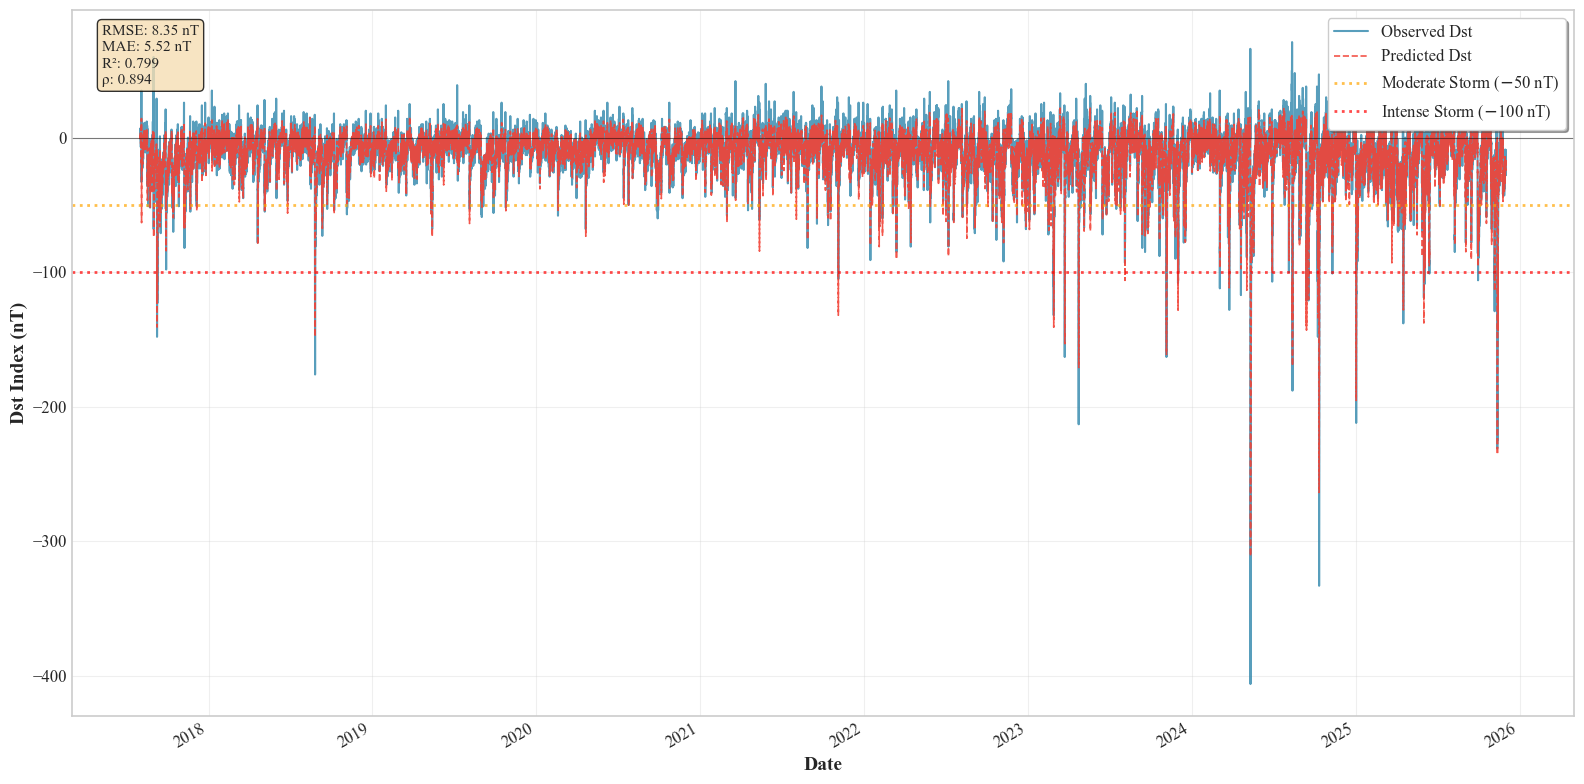

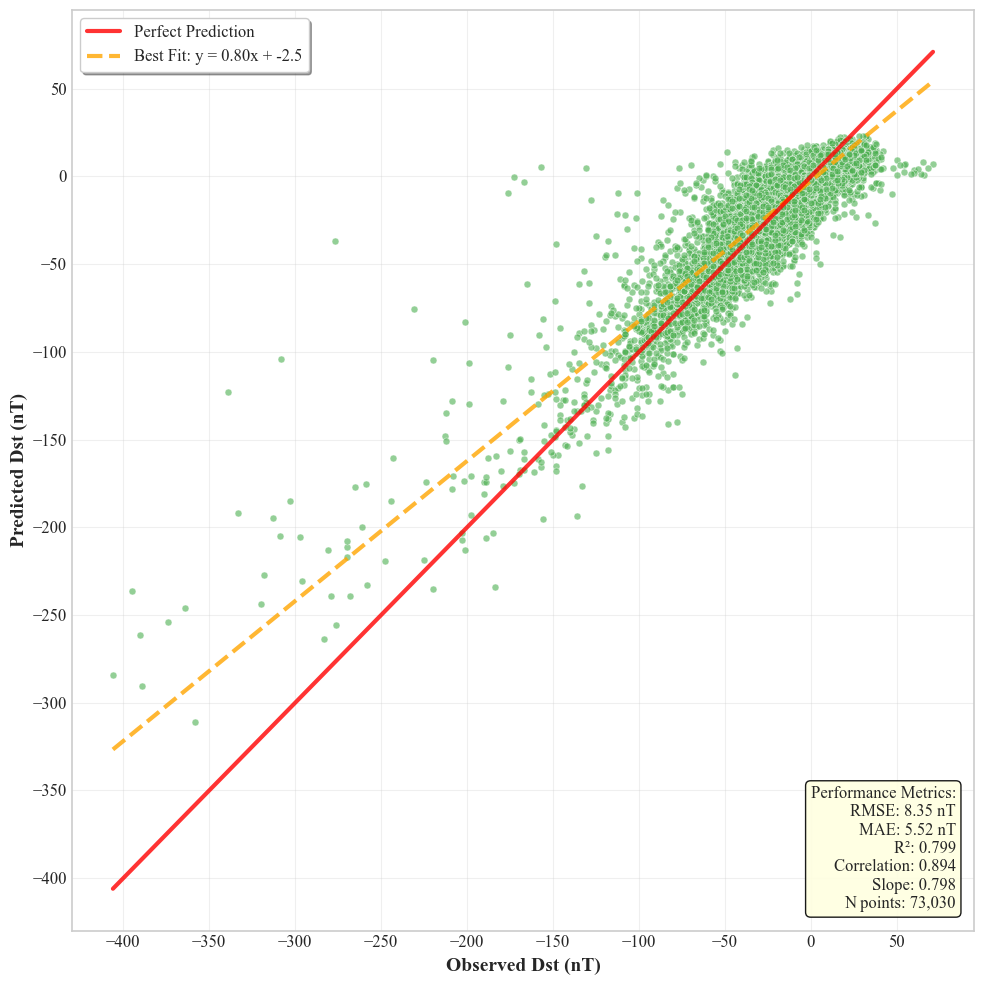

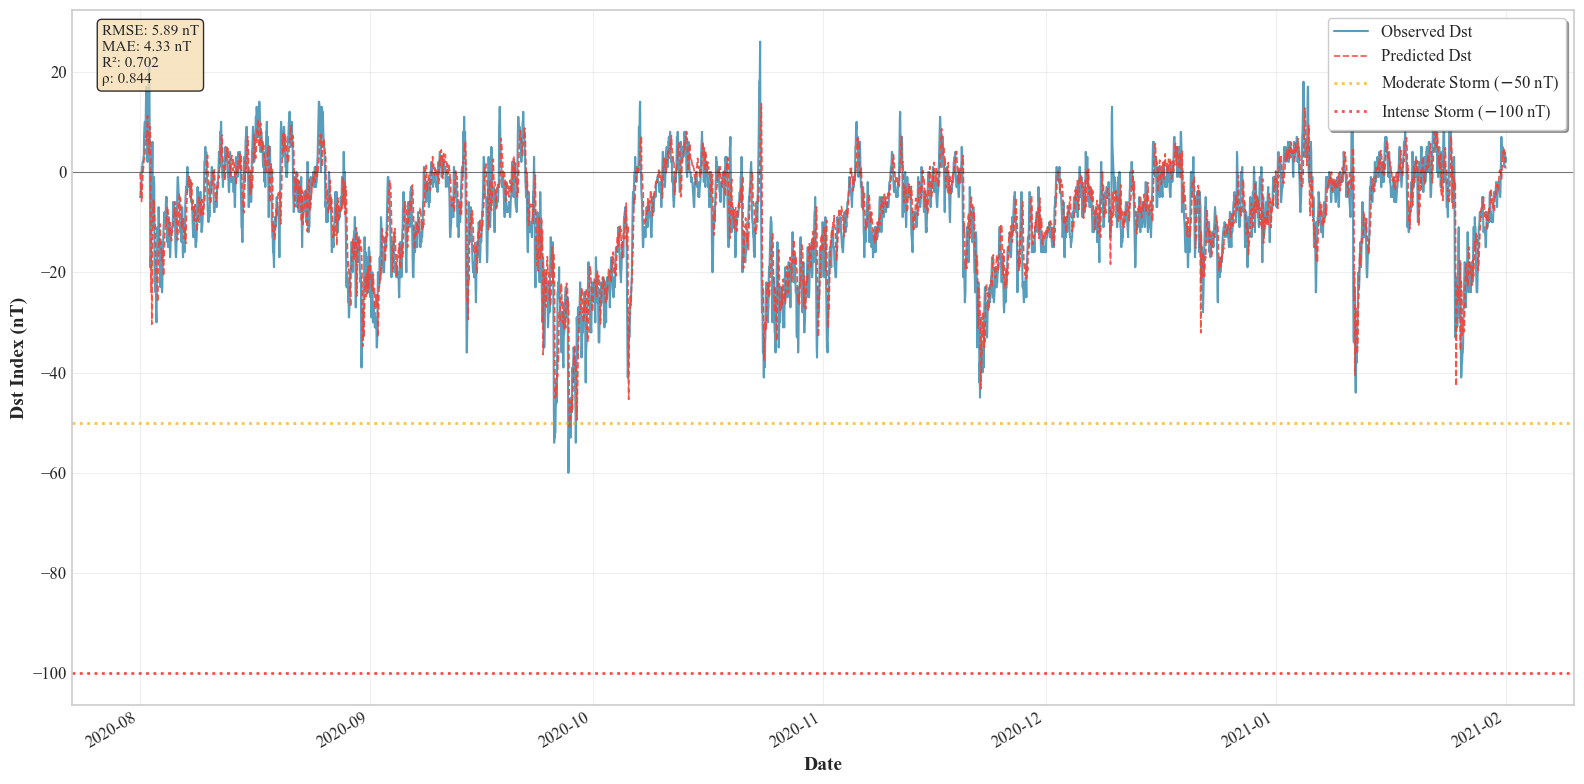

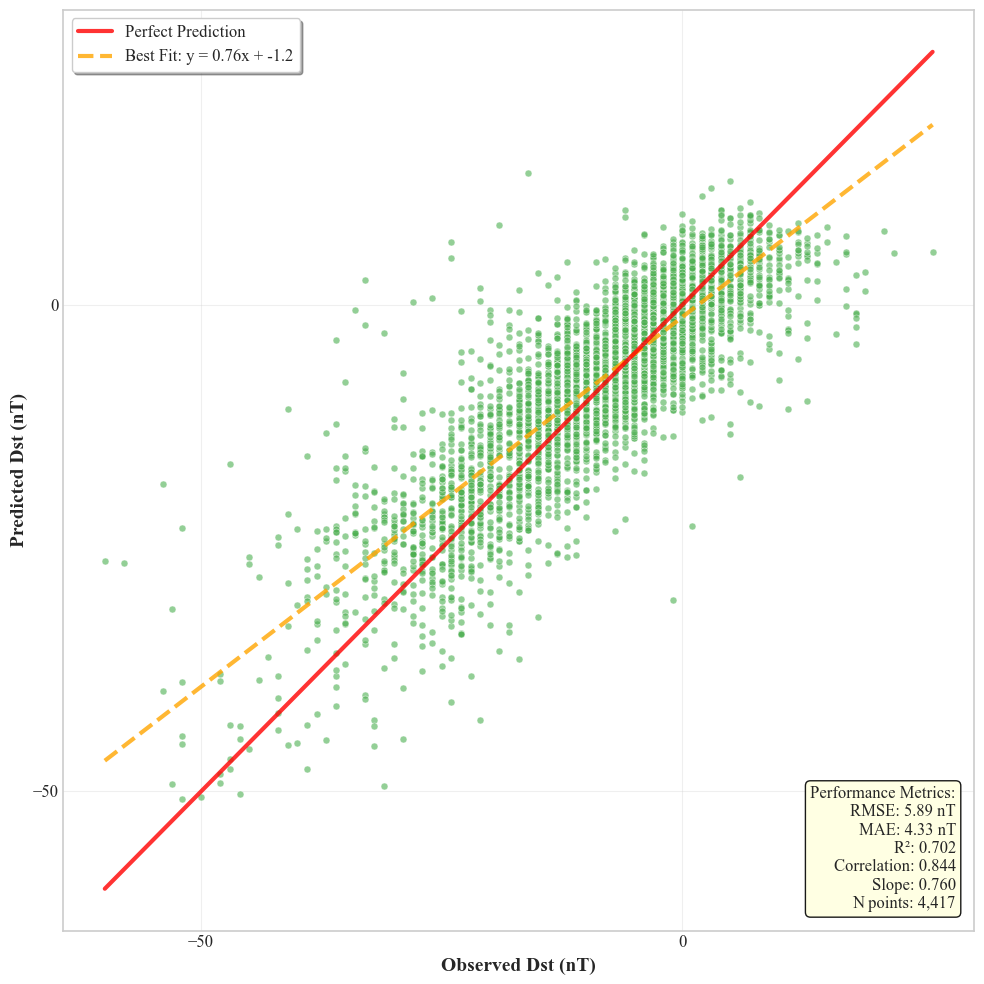

In [21]:
# %load_ext autoreload
# %autoreload 2

import importlib
from data_processing2 import paper_viz

importlib.reload(paper_viz)
from data_processing2.paper_viz import (
    plot_dst_both,
)

"""
2007-01-02 07:00:00 2020-05-30 23:00:00
"""
full_timeseries_fig, full_scatter_fig = plot_dst_both(
    test_data[FULL_DATE_COLUMN].values.tolist(),
    _y_test, 
    _y_test_pred, 
    title="Test Period",
    series_storm_threshold=True,
    scatter_storm_threshold=False,
    hexbin_plot=False,
    save_path="graphs_for_paper2/full_test_BUN"
)

june_septemeber_full_timeseries_fig, june_septemeber_full_scatter_fig = plot_dst_both(
    test_data[paper_mask][FULL_DATE_COLUMN].values.tolist(),
    _y_test[paper_mask], 
    _y_test_pred[paper_mask], 
    title="Test Period",
    series_storm_threshold=True,
    scatter_storm_threshold=False,
    # scatter_figsize=(6, 6),
    hexbin_plot=False,
    save_path=f"graphs_for_paper2/test_{viz_start_date}__{viz_end_date}_BUN"
)

from data_processing2.embeddings import add_takens_embeddings, add_2d_pairs

plasma_speed_example = test_data[[SW_SPEED_COL, DST_COLUMN]].copy()
plasma_speed_example, taken_col_example = add_takens_embeddings(plasma_speed_example, [SW_SPEED_COL], [5], [1])
plasma_speed_example, pair_col = add_2d_pairs(plasma_speed_example, taken_col_example)

quite_trajectories = plasma_speed_example.iloc[10:14][pair_col].values
storm_trajectories = plasma_speed_example.iloc[803:807][pair_col].values

storm_mask = train_data.iloc[1000:1100].copy()
storm_mask = storm_mask[DST_COLUMN] <= -50

### Feature explainability

SHAP (SHapley Additive exPlanations) analysis via `helpers.shap_viz.create_shap_plot()`. Quantifies contribution of each feature to model predictions. Shows separately for storms vs full dataset to understand different decision logic.

In [22]:
# def org_feature_importance(model):
#     feature_important = model.get_score(importance_type='gain')
#     keys = list(feature_important.keys())
#     values = list(feature_important.values())

#     data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=True)
#     data.nlargest(10, columns="score").plot(kind='barh', figsize = (20,10))

# org_feature_importance(xgb_model)

In [20]:
from helpers.shap_viz import create_shap_plot
masked_x_test = x_test[y_test <= -50][:100].copy()
masked_y_test = y_test[y_test <= -50][:100].copy()
dtest_neg = xgb.DMatrix(masked_x_test, label=masked_y_test, enable_categorical=True, weight=sample_weights)

Saved: graphs_for_paper2/long_8hr_shap_negative_dst_test.jpg
Saved: graphs_for_paper2/long_8hr_shap_full_test_latest.jpg


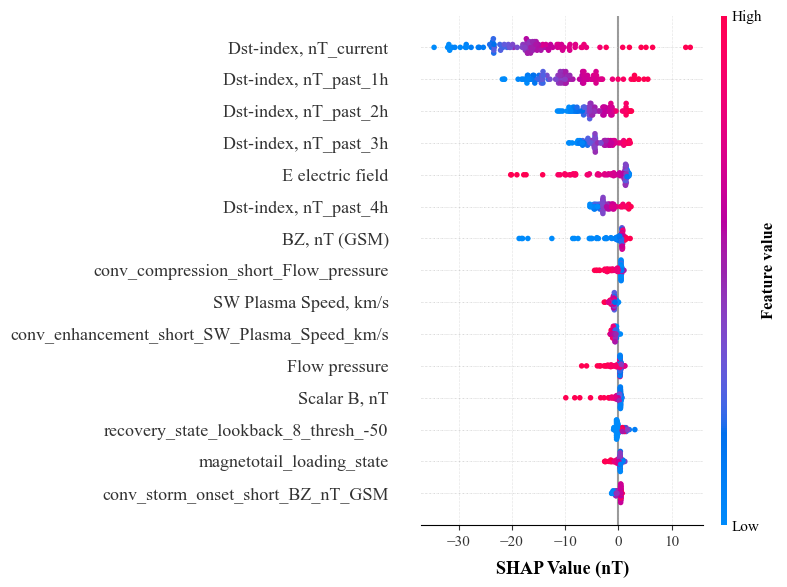

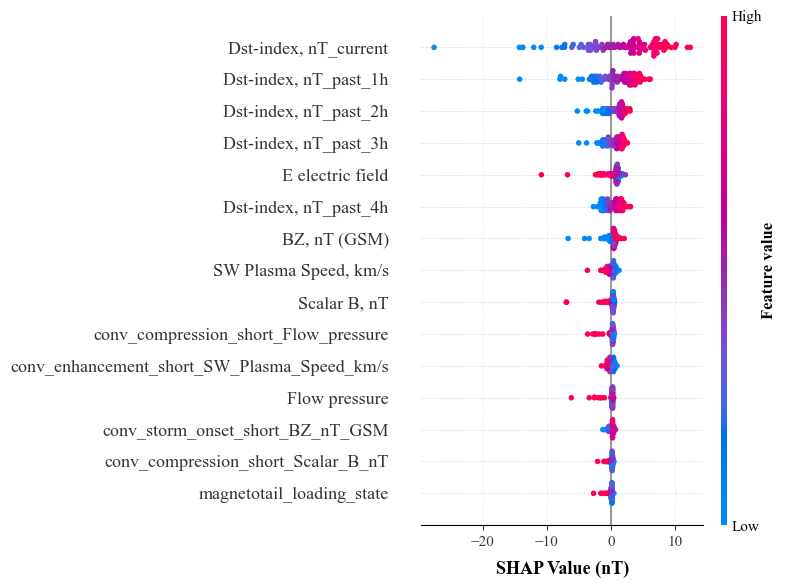

In [21]:
neg_shap_results = create_shap_plot(
    xgb_model, dtest_neg, sample_size=dtest_neg.num_row(), max_features=15, save_path="graphs_for_paper2/long_8hr_shap_negative_dst_test.jpg"
)

full_shap_results = create_shap_plot(
    xgb_model, dtest, sample_size=dtest_neg.num_row(), max_features=15, save_path="graphs_for_paper2/long_8hr_shap_full_test_latest.jpg"
)

### Interaction between features

SHAP interaction analysis via `helpers.shap_viz_interaction.create_shap_interaction_plot()`. Identifies top feature pairs that jointly drive model predictions (synergistic effects).

In [22]:
from helpers.shap_viz_interaction import create_shap_interaction_plot

Interaction values shape: (100, 174, 174)
Saved: graphs_for_paper2/interaction_map.png


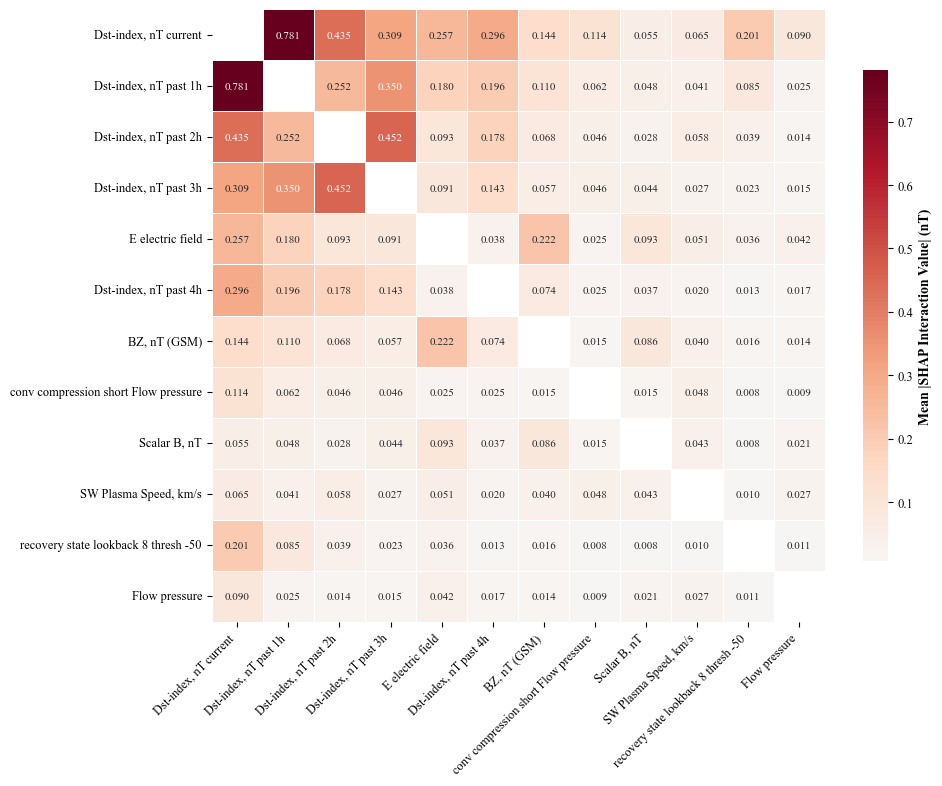

In [23]:
interaction_results = create_shap_interaction_plot(
    xgb_model, dtest_neg, "graphs_for_paper2/interaction_map.png", top_k=12, sample_size=300
)

### ICE PLOTS

Individual Conditional Expectation (ICE) plots via `helpers.ice_plots.create_ice_plot()`. Show how model predictions change as individual features vary, holding others constant. Reveals non-linear decision boundaries for specific features.

In [26]:
dst_mask = (y_test <= -20) & (y_test <= -100)

ICE: 300 samples (305 available after mask).
Saved: graphs_for_paper2/ice_plot_example_magnetotail_loading_state.png


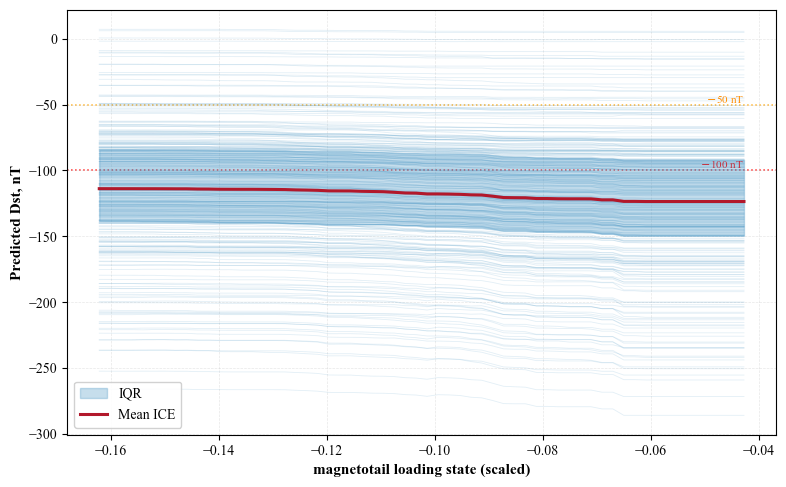

In [27]:
from helpers.ice_plots import create_ice_plot

ice_results = create_ice_plot(
    model = xgb_model, 
    dmatrix = dtest,
    dst_mask = dst_mask,
    vary_feature="magnetotail_loading_state", 
    save_path="graphs_for_paper2/ice_plot_example_magnetotail_loading_state.png",
    sample_size=300,
    is_scaled=True,
)